In [1]:
import nibabel as nib
import os
from neurosynth import decode
from neurosynth import Dataset
from neurosynth.analysis.cluster import Clusterable
import numpy as np
import matplotlib.pyplot as plt
import warnings
from pathlib import Path
import pandas as pd


plt.rcParams['axes.grid'] = False
plt.rcParams['font.family'] = 'Arial'
warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
DATA_PATH = Path('../data')
RESULTS_PATH = Path('../results')
PLOT_PATH = Path('../plots')
DATASET_FILE = DATA_PATH / 'neurosynth_data/dataset.pkl'

In [3]:
DATABASE_PATH = Path('/home/guoqiu/NAS/Dep/Three_Parcels_FC_Profiles/Wanglab_Dataset_denoised')
subject_list = pd.read_csv(DATA_PATH / 'inhouse_subject.tsv')['participant_id'].tolist()
mapping = dict(social='avmpfc', emotion='pvmpfc', valuation='mvmpfc')

for name, pattern in mapping.items():
    data_list = []
    for sub_file in DATABASE_PATH.rglob(f'*{pattern}_FC_z.nii*'):
        sub_img = nib.load(sub_file)
        data_list.append(sub_img.get_fdata())
    print(len(data_list))
    mean_data = np.mean(np.stack(data_list, axis=0), axis=0)
    mean_img = nib.Nifti1Image(mean_data, affine=sub_img.affine, header=sub_img.header)
    nib.save(mean_img, DATA_PATH / f'Parcel_FC/inhouse_age_18_30_resting_{name}_mean_FC_z.nii')

42
42
42


# Decode

In [4]:

dataset = Dataset.load(DATASET_FILE)
print(f'Dataset includes {dataset.feature_table.data.shape[0]} studies.')

Dataset includes 14371 studies.


## inhouse_age_18_30_resting

In [7]:
name = 'inhouse_age_18_30_resting'
term_list = pd.read_csv(DATA_PATH / 'top15_term.csv')['term'].tolist()
decoder = decode.Decoder(dataset=dataset, features=term_list)

decode_result = []
column_list = []
for image_file in (DATA_PATH / 'Parcel_FC').iterdir():
    if not image_file.name.startswith(name):
        continue
    print(image_file.name)
    image = nib.load(image_file)
    new_image_data = image.get_fdata()
    new_image_data = dataset.masker.mask(new_image_data).flatten()[:, np.newaxis]
    column_list.append(image_file.stem.split('_')[5])
    decode_result.append(decoder.decode(images=new_image_data))
decode_15_df = pd.concat(decode_result, axis=1)
decode_15_df.columns = column_list
decode_15_df.to_csv(RESULTS_PATH / f'Neurosynth_decode/{name}_top15_terms.csv')
decode_15_df

inhouse_age_18_30_resting_valuation_mean_FC_z.nii
inhouse_age_18_30_resting_emotion_mean_FC_z.nii
inhouse_age_18_30_resting_social_mean_FC_z.nii


,valuation,emotion,social
autobiographical,0.5123,0.5270,0.5495
reward,0.3408,0.3229,0.1743
social,0.4439,0.4424,0.4809
emotion,0.3785,0.4127,0.3434
value,0.4045,0.3978,0.2895
self,0.4975,0.4604,0.4122
decision making,0.2622,0.1816,0.1215
affective,0.2976,0.3165,0.2290
person,0.2669,0.2613,0.3355
fear,0.2185,0.2661,0.1608


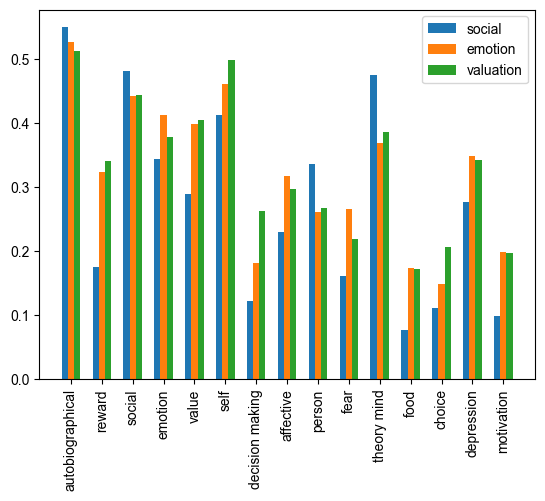

In [8]:
# fast glance on result
fig, ax = plt.subplots()

x = np.arange(len(decode_15_df))
bar_width = 0.2
plt.bar(x - bar_width, decode_15_df['social'], width=bar_width, label='social')
plt.bar(x, decode_15_df['emotion'], width=bar_width, label='emotion')
plt.bar(x + bar_width, decode_15_df['valuation'], width=bar_width, label='valuation')

plt.xticks(x, decode_15_df.index, rotation=90)
plt.legend()

## Test

In [9]:
name = 'test'
term_list = pd.read_csv(DATA_PATH / 'top15_term.csv')['term'].tolist()
decoder = decode.Decoder(dataset=dataset, features=term_list)

decode_result = []
column_list = []
for image_file in (DATA_PATH / 'Parcel_FC').iterdir():
    if not image_file.name.startswith(name):
        continue
    print(image_file.name)
    image = nib.load(image_file)
    new_image_data = image.get_fdata()
    new_image_data = dataset.masker.mask(new_image_data).flatten()[:, np.newaxis]
    column_list.append(image_file.stem.split('_')[1])
    decode_result.append(decoder.decode(images=new_image_data))
decode_15_df = pd.concat(decode_result, axis=1)
decode_15_df.columns = column_list
decode_15_df.to_csv(RESULTS_PATH / f'Neurosynth_decode/{name}_top15_terms.csv')
decode_15_df

test_emotion_pvmpfc_bin.nii.gz
test_social_avmpfc_bin.nii.gz
test_valuation_mvmpfc_bin.nii.gz


,emotion,social,valuation
autobiographical,0.0372,0.1111,0.0504
reward,0.0761,0.1217,0.0967
social,0.0544,0.1351,0.0869
emotion,0.0628,0.0880,0.0681
value,0.0979,0.1646,0.1491
self,0.0778,0.1182,0.1234
decision making,0.0682,0.1150,0.0986
affective,0.0796,0.0767,0.0610
person,-0.0086,0.0974,0.0350
fear,0.0762,0.0779,0.0748


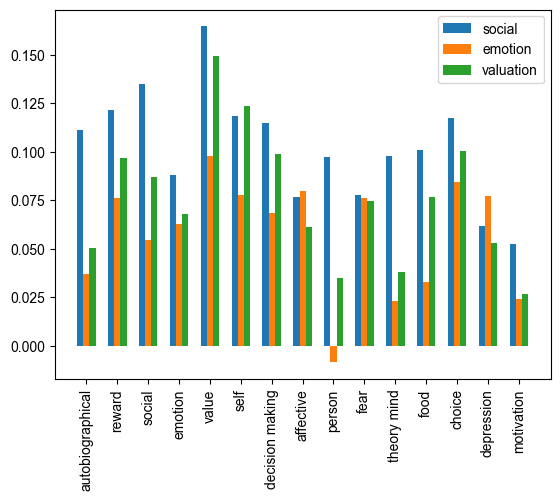

In [10]:
# fast glance on result
fig, ax = plt.subplots()

x = np.arange(len(decode_15_df))
bar_width = 0.2
plt.bar(x - bar_width, decode_15_df['social'], width=bar_width, label='social')
plt.bar(x, decode_15_df['emotion'], width=bar_width, label='emotion')
plt.bar(x + bar_width, decode_15_df['valuation'], width=bar_width, label='valuation')

plt.xticks(x, decode_15_df.index, rotation=90)
plt.legend()